# Final plots

Paper figures for the controllability-elicitation results. Every figure cell below
imports style, palette, model/method names and the `save()` helper from the setup
cell, so changing a colour or a label here changes it everywhere. Sections follow
the order figures appear in the paper; figures not in the paper go at the end.
Run from the repo root with the `.venv` kernel.


## Setup


In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

%config InlineBackend.figure_format = 'retina'

REPO = Path.cwd().resolve()
while not (REPO / "cotcontrol").is_dir():      # allow running from a subfolder
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from utils import PALETTE, set_matplotlib_style
from cotcontrol.eval.data import CONSTRAINT_MODES
from cotcontrol.eval.prompts import EXTENDED_MODES, HELDOUT_MODES

# ---------------------------------------------------------------------------
# Style. utils.set_matplotlib_style() is the repo-wide look (sans-serif, no
# top/right spines, recessive y-grid, frameless legends, CVD-safe cycle); the
# overrides below make it camera-ready: Helvetica-metric fonts (TeX Gyre Heros /
# Liberation Sans are installed here), centred plain panel titles, Type-42 fonts
# so PDF text stays editable, 300 dpi.
# ---------------------------------------------------------------------------
set_matplotlib_style()
plt.rcParams.update({
    "font.sans-serif": ["Helvetica", "Helvetica Neue", "TeX Gyre Heros",
                        "Liberation Sans", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stixsans",
    "axes.titlelocation": "center",
    "axes.titleweight": "normal",
    "axes.grid.axis": "both",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

INK, GRAY, LIGHT = "#0b0b0b", "#898781", "#c3c2b7"   # text / reference lines / chrome
BASELINE_COLOR = "#333333"                            # "no intervention" curves & bars

# ---------------------------------------------------------------------------
# Page geometry. Figures are drawn wider than they print, so fonts are scaled
# by the inverse of the shrink factor. TEXT_WIDTH_IN is the NeurIPS \textwidth;
# update from paper/main.tex if the template changes.
# ---------------------------------------------------------------------------
TEXT_WIDTH_IN = 469.75502 / 72.27
FIG_DIR = REPO / "paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def paper_fonts(fig_width_in, frac=1.0, label_pt=8.0, tick_pt=7.5):
    """Scale font rcParams so a figure saved `fig_width_in` wide and included at
    `frac` * \textwidth prints labels/legends at `label_pt` and ticks at `tick_pt`.
    Call before creating the figure; returns the scale for explicit fontsize=."""
    s = fig_width_in / (TEXT_WIDTH_IN * frac)
    plt.rcParams.update({
        "font.size": label_pt * s,
        "axes.labelsize": label_pt * s,
        "legend.fontsize": label_pt * s,
        "xtick.labelsize": tick_pt * s,
        "ytick.labelsize": tick_pt * s,
        "axes.titlesize": (label_pt + 1.0) * s,
        "figure.titlesize": (label_pt + 1.5) * s,
        "figure.labelsize": label_pt * s,
    })
    return s


def save(fig, name, png=True):
    """Write paper/figures/<name>.pdf (+ .png preview). Returns the pdf path."""
    pdf = FIG_DIR / f"{name}.pdf"
    fig.savefig(pdf, bbox_inches="tight")
    if png:
        fig.savefig(pdf.with_suffix(".png"), bbox_inches="tight", dpi=200)
    print("saved", pdf.relative_to(REPO))
    return pdf


def panel_labels(axes, x=-0.12, y=1.02, **kw):
    """(a), (b), ... in the top-left corner of each axis."""
    for ax, ch in zip(np.ravel(axes), "abcdefghij"):
        ax.text(x, y, f"({ch})", transform=ax.transAxes, ha="left", va="bottom",
                fontweight="bold", color=INK, **kw)


def legend_below(fig, ax=None, ncol=None, y=0.0, **kw):
    """One frameless legend centred under the figure, using the handles of `ax`
    (default: first axis). Call after tight_layout; y<0 pushes it further down."""
    h, l = (ax or fig.axes[0]).get_legend_handles_labels()
    return fig.legend(h, l, loc="upper center", bbox_to_anchor=(0.5, y),
                      ncol=ncol or len(l), **kw)


def shade(color, t):
    """Tint/darken `color`: t<0.5 blends toward white, t>0.5 toward black, 0.5 = as is."""
    rgb = np.array(mcolors.to_rgb(color))
    if t <= 0.5:
        w = 0.25 + 1.5 * t                      # 25% hue at t=0 -> full hue at t=0.5
        return tuple(rgb * w + (1 - w))
    return tuple(rgb * (1 - 0.9 * (t - 0.5)))   # -> 55% toward black at t=1


def ramp(color, n):
    """n ordered shades of one hue, pale -> dark, for an ordinal knob (k, rank, epochs)."""
    return [shade(color, t) for t in np.linspace(0.15, 0.9, n)]


def binom_se(p, n):
    """Std. error of a rate p estimated from n rollouts (test split: n=N_TEST)."""
    p = np.asarray(p, dtype=float)
    return np.sqrt(p * (1 - p) / n)

# ---------------------------------------------------------------------------
# Canonical names. Keys match run/baseline folder names (baselines/<key>,
# gepa/runs/*/<key>_*, sft/runs/*_<key>_*). Colour follows the model, never its
# rank: one hue per family (the paper's ceilings are family properties), light
# = smaller model. The four locally trained models come first.
# ---------------------------------------------------------------------------
FAMILY_HUE = {"gpt-oss": PALETTE[0], "Qwen": PALETTE[1], "Kimi": PALETTE[2],
              "GLM": PALETTE[3], "DeepSeek": PALETTE[4], "Nemotron": PALETTE[5]}

MODELS = [  # (key, display name, family, shade t)
    ("gptoss20b",    "gpt-oss-20b",       "gpt-oss",  0.30),
    ("gptoss120b",   "gpt-oss-120b",      "gpt-oss",  0.75),
    ("qwen8b",       "Qwen3-8B",          "Qwen",     0.30),
    ("qwen32b",      "Qwen3-32B",         "Qwen",     0.75),
    ("qwen36a3b",    "Qwen3.6-35B-A3B",   "Qwen",     0.50),
    ("qwen36_27b",   "Qwen3.6-27B",       "Qwen",     0.50),
    ("qwen38_27b",   "Qwen3.8-27B",       "Qwen",     0.50),
    ("qwen38_2.4t",  "Qwen3.8-2.4T",      "Qwen",     0.95),
    ("kimik26",      "Kimi-K2.6",         "Kimi",     0.30),
    ("kimik3",       "Kimi-K3",           "Kimi",     0.65),
    ("glm52",        "GLM-5.2",           "GLM",      0.30),
    ("glm53flash",   "GLM-5.3-Flash",     "GLM",      0.50),
    ("glm53",        "GLM-5.3",           "GLM",      0.75),
    ("dsv4pro",      "DeepSeek-V4-Pro",   "DeepSeek", 0.55),
    ("nemotron3ultra", "Nemotron-3-Ultra", "Nemotron", 0.55),
]
MODEL_LABEL = {k: name for k, name, _, _ in MODELS}
MODEL_FAMILY = {k: fam for k, _, fam, _ in MODELS}
MODEL_COLOR = {k: shade(FAMILY_HUE[fam], t) for k, _, fam, t in MODELS}
TRAINED_MODELS = ["gptoss20b", "gptoss120b", "qwen8b", "qwen32b"]   # SFT/RL/SDF arms

# Elicitation methods, in the order they appear in the paper. Fixed palette
# slots (identity, never rank); baseline is always the dark neutral.
METHODS = [  # (key, display name, colour)
    ("baseline", "Baseline (no elicitation)",  BASELINE_COLOR),
    ("gepa",     "GEPA prompt optimisation",   PALETTE[0]),
    ("fewshot",  "Few-shot demonstrations",    PALETTE[1]),
    ("agent",    "Agent prompt optimisation",  PALETTE[2]),
    ("bon",      "Best-of-n",                  PALETTE[3]),
    ("sft",      "SFT (masked LoRA)",          PALETTE[4]),
    ("rl",       "RL (GRPO)",                  PALETTE[5]),
    ("sdf",      "Synthetic-document FT",      PALETTE[6]),
]
METHOD_LABEL = {k: name for k, name, _ in METHODS}
METHOD_COLOR = {k: c for k, _, c in METHODS}

# Metrics -> axis labels. "strict" = compliance graded on a non-degenerate
# trace (>= 200 reasoning chars, not truncated, answer extracted, low
# repetition); "compliance" = raw grader hit; "accuracy" = answer correct.
METRIC_LABEL = {
    "strict_compliance":  "Strict compliance",
    "compliance":         "Compliance",
    "shaped_compliance":  "Shaped compliance",
    "accuracy":           "Accuracy",
    "reasoning_chars":    "Reasoning length (chars)",
}

# Evaluation blocks (constraint-mode pools) and canonical split sizes.
BLOCKS = [("cotcontrol", f"Main ({len(CONSTRAINT_MODES)} modes)"),
          ("heldout",    f"Held-out ({len(HELDOUT_MODES)} modes)"),
          ("extended",   f"Extended ({len(EXTENDED_MODES)} modes)")]
BLOCK_LABEL = dict(BLOCKS)
N_TRAIN, N_VAL, N_TEST = 514, 200, 500

print(f"repo {REPO} | figures -> {FIG_DIR.relative_to(REPO)} | "
      f"modes main/heldout/extended = {len(CONSTRAINT_MODES)}/{len(HELDOUT_MODES)}/{len(EXTENDED_MODES)}")


repo /root/controllability-elicitation | figures -> paper/figures | modes main/heldout/extended = 9/3/18


## Prompting results


### Strict compliance vs. reasoning length on the held-out modes

Prompting interventions raise compliance **and** shorten reasoning traces, and shorter
traces are mechanically easier to keep compliant. To separate the two effects we stratify
per-rollout strict compliance by reasoning length, one panel per model, one curve per
(arm, seed). A curve **above the baseline at the same length** means the gain is not a
length effect.

Binning follows CoT-Control Fig. 1c/23 (arXiv 2603.05706, inferred from the figures; their repo
has no plotting code): each curve's 1500 rollouts (pooled over the 3 modes and 3 datasets) are
split into 10 equal-count bins by length, each point sits at the bin's median length with a
one-SE error bar. Per arm we show the **best of the 3 seeds** (highest overall held-out strict compliance,
all 1500 rollouts, independent of length); the all-seeds version is in the Appendix. Unlike the paper we keep a linear y-axis (many of our bins are exactly 0%)
and use characters rather than words (see below). `BINNING = "grid"` switches to a shared
global log-spaced grid instead.

Data: the **pinned re-evaluation** (`pinned_reeval/`, 2026-09-22): every model served by one fixed
OpenRouter provider, temperature 0, 16k max tokens, model-native reasoning effort (gpt-oss: medium,
i.e. the Harmony default used in training), settings in `configs/eval_pins.json`. Arms: empty-prompt
baseline, GEPA (the general-advice arm; 3 seeds, s0 = `initial_sweep`, s1/s2 = `second_sweep`
best prompts) and few-shot k=1 (3 seeds), all re-evaluated on the **held-out control modes**
(`start_of_sentence`, `letter_suppression`, `no_spaces`), never seen by any optimiser, on the canonical
test questions: 500 questions x 3 modes = 1500 rollouts per run. Length is in **characters** because
`no_spaces` traces have no word boundaries. Errored rollouts (3 of 84k, all one provider's rate limits)
are excluded.

**(Near-)empty traces are excluded** (`MIN_CHARS = 20`), but with fixed providers they are rare:
72 of the 84k held-out rollouts have fewer than 20 characters (55 at 0-4, 17 at 5-19; real traces
resume at 20+), at most 1.8% of any single run (GLM-5.3 GEPA). In the earlier mixed-provider evals
6.5k of 120k rollouts were empty, 11-16% for DeepSeek-V4-Pro in every arm; that was a serving
artefact of particular providers, not a model property. An empty trace is not a controlled CoT but
the absence of one, so it is dropped from the length stratification; per-run shares are the `empty`
column of the table above.


In [2]:
# Per-rollout held-out cache for the prompting arms: one row per (model, arm, seed, rollout).
# Source: the pinned re-evaluation (pinned_reeval/runs/<model>/<arm>_<seed>_heldout/), one fixed
# provider per model, T=0, 16k, meta-discussion judge on (configs/eval_pins.json). Reads the eval
# JSONs once (parallel), then persists a small parquet next to the figures.
from concurrent.futures import ProcessPoolExecutor

PROMPT_MODELS = [k for k in MODEL_LABEL if k in
                 {"gptoss20b", "gptoss120b", "qwen8b", "qwen32b",
                  "kimik3", "glm53flash", "glm53", "dsv4pro"}]         # setup-cell order
PROMPT_ARMS = [  # (key, label, colour, linestyle)
    ("baseline", "Baseline (empty prompt)",   BASELINE_COLOR,          "-"),
    ("gepa",     "GEPA",                      METHOD_COLOR["gepa"],    "-"),
    ("fewshot",  "Few-shot (k=1)",            METHOD_COLOR["fewshot"], "-"),
]
PROMPT_SEEDS = {"baseline": ["-"], "gepa": ["s0", "s1", "s2"], "fewshot": ["s1", "s2", "s3"]}
PINNED = REPO / "pinned_reeval/runs"
HO_CACHE = REPO / "paper/cache/pinned_prompting_heldout_rollouts.parquet"


def pinned_run_dir(key, arm, seed, split):
    """pinned_reeval/runs/<model>/<arm>[_<seed>]_<split>/ (split = 'test' | 'heldout')."""
    name = f"{arm}_{split}" if arm == "baseline" else f"{arm}_{seed}_{split}"
    return PINNED / key / name


def heldout_run_dir(key, arm, seed):
    return pinned_run_dir(key, arm, seed, "heldout")


def eval_file(d):
    """The single per-rollout eval JSON in a run dir (timestamped *_all_all.json)."""
    fs = [p for p in d.glob("*.json") if p.name != "summary.json"]
    assert len(fs) == 1, (d, fs)
    return fs[0]


def _load_rollouts(job):
    key, arm, seed = job
    with open(eval_file(heldout_run_dir(key, arm, seed))) as f:
        results = json.load(f)["results"]
    rows = []
    for r in results:
        s = r["samples"][0]
        t = s.get("reasoning") or ""
        rows.append({"model": key, "arm": arm, "seed": seed, "mode": r["mode"],
                     "dataset": r["dataset"], "error": bool(s.get("error")),
                     "reasoning_chars": len(t), "reasoning_words": len(t.split()),
                     "compliance": int(s["compliance"] == 1), "correct": bool(s["correct"])})
    return rows


def load_heldout_rollouts(refresh=False):
    if HO_CACHE.exists() and not refresh:
        return pd.read_parquet(HO_CACHE)
    jobs = [(k, arm, s) for k in PROMPT_MODELS for arm, *_ in PROMPT_ARMS for s in PROMPT_SEEDS[arm]]
    with ProcessPoolExecutor(max_workers=32) as ex:
        df = pd.DataFrame([row for rows in ex.map(_load_rollouts, jobs) for row in rows])
    HO_CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(HO_CACHE, index=False)
    return df


ho = load_heldout_rollouts()
assert (ho.groupby(["model", "arm", "seed"]).size() == 3 * N_TEST).all(), "expected 1500 rollouts per run"
ho_runs = (ho.assign(empty=ho["reasoning_chars"] < 20)
             .groupby(["model", "arm", "seed"])
             .agg(n=("compliance", "size"), errors=("error", "sum"),
                  strict=("compliance", "mean"), chars=("reasoning_chars", "mean"),
                  empty=("empty", "mean"))
             .round(3))
print(f"{len(ho):,} rollouts over {len(ho_runs)} runs; cache {HO_CACHE.relative_to(REPO)}")
# strict = strict compliance, chars = mean reasoning length, empty = share of (near-)empty traces (<20 chars)
ho_runs.unstack("seed")[["strict", "chars", "empty"]].reindex(PROMPT_MODELS, level="model")


84,000 rollouts over 56 runs; cache paper/cache/pinned_prompting_heldout_rollouts.parquet


strict                                  chars             \
seed                     -     s0     s1     s2     s3          -         s0   
model      arm                                                                 
gptoss20b  baseline  0.013    NaN    NaN    NaN    NaN   9164.457        NaN   
           fewshot     NaN    NaN  0.061  0.042  0.073        NaN        NaN   
           gepa        NaN  0.134  0.251  0.210    NaN        NaN  16315.771   
gptoss120b baseline  0.049    NaN    NaN    NaN    NaN   2930.237        NaN   
           fewshot     NaN    NaN  0.152  0.298  0.203        NaN        NaN   
           gepa        NaN  0.080  0.126  0.129    NaN        NaN   3528.384   
qwen8b     baseline  0.001    NaN    NaN    NaN    NaN  12155.599        NaN   
           fewshot     NaN    NaN  0.004  0.004  0.003        NaN        NaN   
           gepa        NaN  0.001  0.001  0.001    NaN        NaN   7075.869   
qwen32b    baseline  0.005    NaN    NaN    NaN    NaN  11681.301        NaN   
           fewshot     NaN    NaN  0.007  0.007  0.009        NaN        NaN   
           gepa        NaN  0.009  0.009  0.005    NaN        NaN  10377.768   
kimik3     baseline  0.047    NaN    NaN    NaN    NaN  24866.111        NaN   
           fewshot     NaN    NaN  0.269  0.197  0.221        NaN        NaN   
           gepa        NaN  0.284  0.316  0.341    NaN        NaN  19168.501   
glm53flash baseline  0.004    NaN    NaN    NaN    NaN  26465.988        NaN   
           fewshot     NaN    NaN  0.000  0.000  0.000        NaN        NaN   
           gepa        NaN  0.005  0.036  0.014    NaN        NaN  26977.539   
glm53      baseline  0.015    NaN    NaN    NaN    NaN  27092.979        NaN   
           fewshot     NaN    NaN  0.000  0.000  0.001        NaN        NaN   
           gepa        NaN  0.027  0.007  0.020    NaN        NaN  24588.791   
dsv4pro    baseline  0.000    NaN    NaN    NaN    NaN  24297.569        NaN   
           fewshot     NaN    NaN  0.159  0.113  0.048        NaN        NaN   
           gepa        NaN  0.003  0.004  0.017    NaN        NaN  20679.250   

                                                      empty                \
seed                        s1         s2         s3      -     s0     s1   
model      arm                                                              
gptoss20b  baseline        NaN        NaN        NaN  0.000    NaN    NaN   
           fewshot    9555.009  12059.411  13016.365    NaN    NaN  0.000   
           gepa      10890.862  14972.887        NaN    NaN  0.000  0.000   
gptoss120b baseline        NaN        NaN        NaN  0.000    NaN    NaN   
           fewshot    2526.533   1695.321   2158.089    NaN    NaN  0.000   
           gepa       3827.211   3178.037        NaN    NaN  0.000  0.000   
qwen8b     baseline        NaN        NaN        NaN  0.000    NaN    NaN   
           fewshot    5144.209   5656.863   5405.585    NaN    NaN  0.000   
           gepa      12162.581  12243.607        NaN    NaN  0.000  0.000   
qwen32b    baseline        NaN        NaN        NaN  0.000    NaN    NaN   
           fewshot    9396.384   9611.207   9085.677    NaN    NaN  0.000   
           gepa      10608.693  10274.012        NaN    NaN  0.000  0.004   
kimik3     baseline        NaN        NaN        NaN  0.000    NaN    NaN   
           fewshot   15845.129  16375.419  15830.679    NaN    NaN  0.000   
           gepa      13853.343   8777.430        NaN    NaN  0.001  0.002   
glm53flash baseline        NaN        NaN        NaN  0.002    NaN    NaN   
           fewshot   26286.562  28827.343  24730.361    NaN    NaN  0.000   
           gepa      21310.033  24385.613        NaN    NaN  0.000  0.000   
glm53      baseline        NaN        NaN        NaN  0.003    NaN    NaN   
           fewshot   30921.247  31105.962  30757.600    NaN    NaN  0.002   
           gepa      23547.929  23111.327        NaN    NaN  0.003  0.010   
dsv4pro    

saved paper/figures/prompting_heldout_compliance_vs_length.pdf


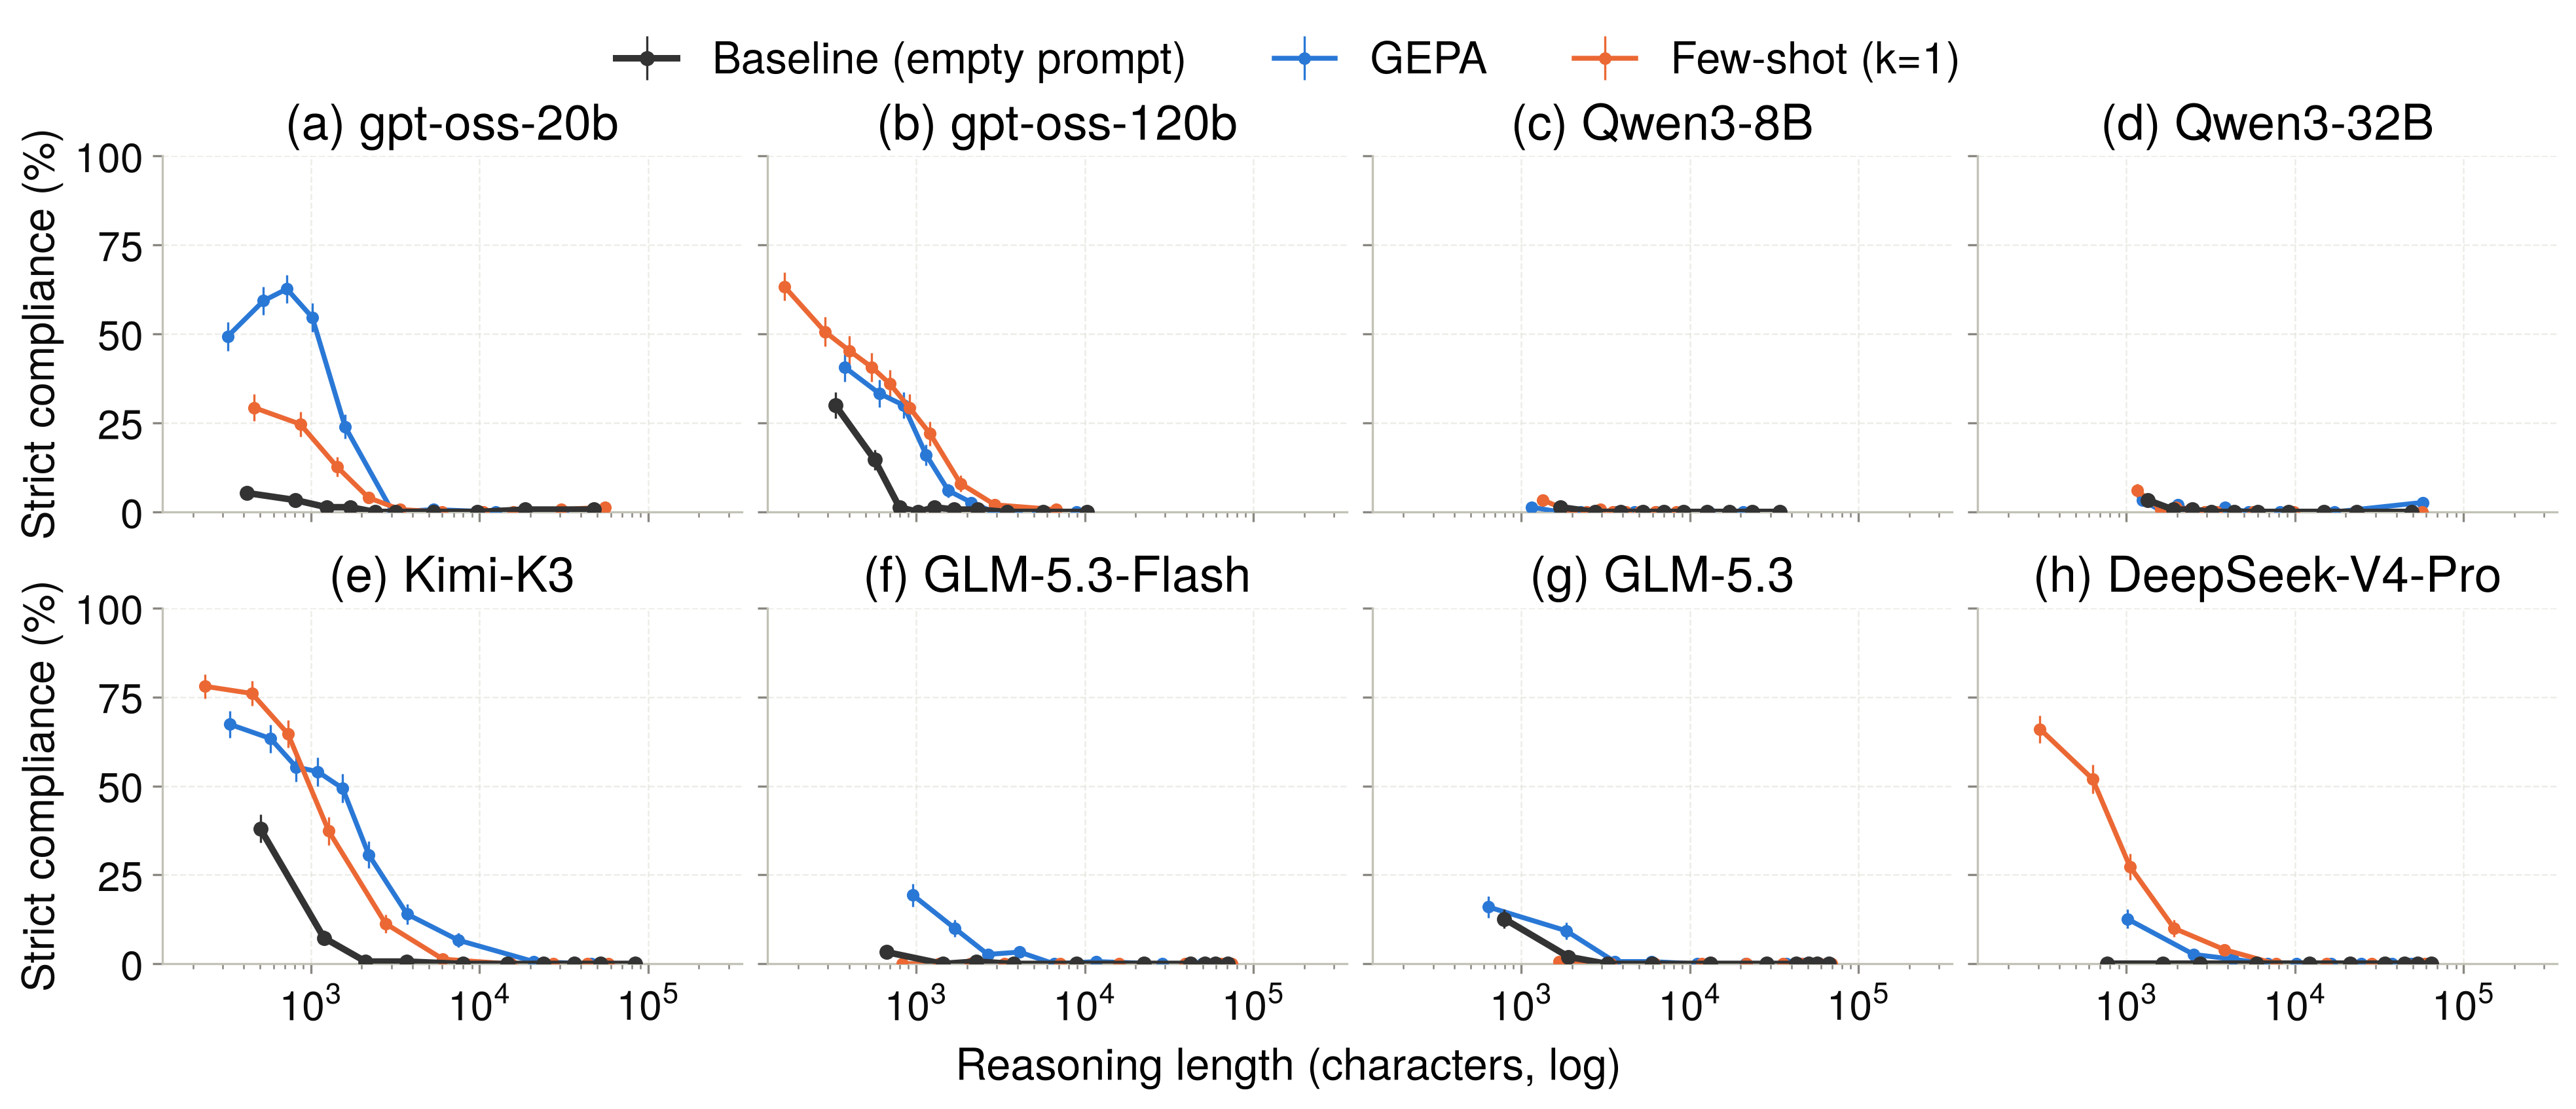

In [3]:
# Binning follows CoT-Control Fig. 1c / 23 (arXiv 2603.05706): per-curve equal-count bins,
# point at the bin's median length, one-SE error bars. "grid" = a global log-spaced grid
# (comparable x across curves, but uneven point counts and dropped bins).
BINNING = "quantile"          # "quantile" | "grid"
N_QBINS = 10                  # 1500 rollouts / 10 = 150 per point
MIN_BIN_N = 50                # grid mode only
# Traces shorter than MIN_CHARS are (near-)empty, i.e. no CoT to control: 6.5k rollouts sit at
# 0-4 chars, 49 at 5-19, and real traces resume at 20+, so any cutoff in the gap selects the same
# set. They are excluded from the length stratification (see ho_runs["empty"] for their share).
MIN_CHARS = 20
MIN_KEPT = 3 * N_TEST // 2    # omit a run's curve if < half its rollouts survive the cutoff
ho_ok = ho[~ho["error"] & (ho["reasoning_chars"] >= MIN_CHARS)].copy()
grid = np.geomspace(MIN_CHARS, ho_ok["reasoning_chars"].max() * 1.001, 22)

# Best seed per (model, arm) = highest held-out strict compliance over ALL 1500 rollouts
# (empties included, i.e. independent of the length cutoff).
best_seed = ho_runs["strict"].groupby(level=["model", "arm"]).idxmax().map(lambda t: t[2])


def binned(sub, col="reasoning_chars"):
    """Rows of (x, mean strict compliance, binomial SE, n). Quantile mode: N_QBINS equal-count
    bins by rank, x = median length; runs with too few kept rollouts return NaN. Grid mode: fixed
    log bins, NaN where n < MIN_BIN_N so curves break instead of bridging empty stretches."""
    if BINNING == "quantile":
        srt = sub.sort_values(col)
        if len(srt) < MIN_KEPT:                  # run is mostly empty traces: omit its curve
            return np.full((1, 4), np.nan)
        out = []
        for pos in np.array_split(np.arange(len(srt)), N_QBINS):
            chunk = srt.iloc[pos]
            p = chunk["compliance"].mean()
            out.append((chunk[col].median(), p, np.sqrt(p * (1 - p) / len(chunk)), len(chunk)))
        return np.array(out)
    idx = np.digitize(sub[col], grid) - 1
    out = np.full((len(grid) - 1, 4), np.nan)
    for b in range(len(grid) - 1):
        m = idx == b
        if m.sum() < MIN_BIN_N:
            continue
        p = sub.loc[m, "compliance"].mean()
        out[b] = (np.sqrt(grid[b] * grid[b + 1]), p, np.sqrt(p * (1 - p) / m.sum()), m.sum())
    return out


def plot_heldout_length(name, all_seeds=False):
    """2x4 panels of strict compliance vs reasoning length on the held-out modes. Per arm the best
    seed is bold with error bars; all_seeds=True adds the other two seeds as faint lines."""
    paper_fonts(13, frac=1.0)
    fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True, sharey=True, layout="constrained")
    for ax, key, ch in zip(axes.flat, PROMPT_MODELS, "abcdefgh"):
        mdf = ho_ok[ho_ok["model"] == key]
        for arm, label, color, ls in PROMPT_ARMS:
            for s in PROMPT_SEEDS[arm]:
                base = arm == "baseline"
                best = base or s == best_seed[key, arm]
                if not (best or all_seeds):
                    continue
                pts = binned(mdf[(mdf["arm"] == arm) & (mdf["seed"] == s)])
                if np.isnan(pts[:, 1]).all():
                    continue
                cx, p, se, n = pts.T
                ax.errorbar(cx, 100 * p, yerr=100 * se if best else None, color=color, ls=ls,
                            marker="o", ms=4.5 if base else (3.6 if best else 2.5),
                            lw=2.4 if base else (1.8 if best else 0.9), elinewidth=0.8, capsize=0,
                            alpha=1.0 if best else 0.35, zorder=5 if base else (4 if best else 2),
                            label=label if best else None)
        ax.set_xscale("log")
        ax.set_xlim(ho_ok["reasoning_chars"].quantile(0.005) / 1.3, grid[-1])
        ax.set_ylim(0, 100)
        ax.set_title(f"({ch}) {MODEL_LABEL[key]}")
        ax.grid(True, which="major", axis="both")
    for ax in axes[:, 0]:
        ax.set_ylabel(f"{METRIC_LABEL['strict_compliance']} (%)")
    fig.supxlabel("Reasoning length (characters, log)")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    if all_seeds:
        handles += [Line2D([], [], color=GRAY, lw=1.8, marker="o", ms=3.6),
                    Line2D([], [], color=GRAY, lw=0.9, alpha=0.35, marker="o", ms=2.5)]
        labels += ["best of 3 seeds", "other seeds"]
    fig.legend(handles, labels, loc="outside upper center", ncol=len(labels))
    save(fig, name)
    return fig


plot_heldout_length("prompting_heldout_compliance_vs_length")
plt.show()


### In-distribution vs. held-out gains from prompting

Two headlines: prompting *consistently* raises controllability in distribution, and *sometimes*
does so out of distribution. One group per model with four bars: two prompting arms (GEPA,
few-shot k=1) x two splits, all from the pinned re-evaluation (one fixed provider per model, T=0,
16k; `pinned_reeval/`). **In-distribution** = strict compliance on the main test split (9 training
modes, n=4464); **held-out** = strict compliance on the 3 held-out modes (n=1500), for the **same
prompt**: per arm, the best of 3 seeds selected on the in-distribution score. Because the prompt is
chosen before looking at the held-out modes, the held-out bar is an unbiased transfer measure.
Dashed marks are the empty-prompt baseline on the same split; hollow dots show all 3 seeds of each
arm on that split. Error bars are one binomial SE.


,base_indist,base_heldout,gepa_seed,gepa_indist,gepa_heldout,fewshot_seed,fewshot_indist,fewshot_heldout,gepa_gain_indist,gepa_gain_heldout,fewshot_gain_indist,fewshot_gain_heldout
key,,,,,,,,,,,,
gptoss20b,0.006,0.013,s1,0.186,0.251,s2,0.153,0.042,0.180,0.238,0.147,0.029
gptoss120b,0.023,0.049,s1,0.214,0.126,s2,0.339,0.298,0.191,0.077,0.316,0.249
qwen8b,0.009,0.001,s1,0.011,0.001,s2,0.136,0.004,0.002,0.000,0.127,0.003
qwen32b,0.027,0.005,s1,0.126,0.009,s2,0.207,0.007,0.099,0.004,0.180,0.002
kimik3,0.056,0.047,s2,0.570,0.341,s1,0.336,0.269,0.514,0.295,0.280,0.222
glm53flash,0.018,0.004,s1,0.077,0.036,s3,0.013,0.000,0.059,0.032,-0.005,-0.004
glm53,0.050,0.015,s0,0.121,0.027,s2,0.041,0.000,0.071,0.012,-0.009,-0.015
dsv4pro,0.009,0.000,s2,0.142,0.017,s1,0.268,0.159,0.133,0.017,0.259,0.159


saved paper/figures/prompting_indist_vs_heldout_gains.pdf


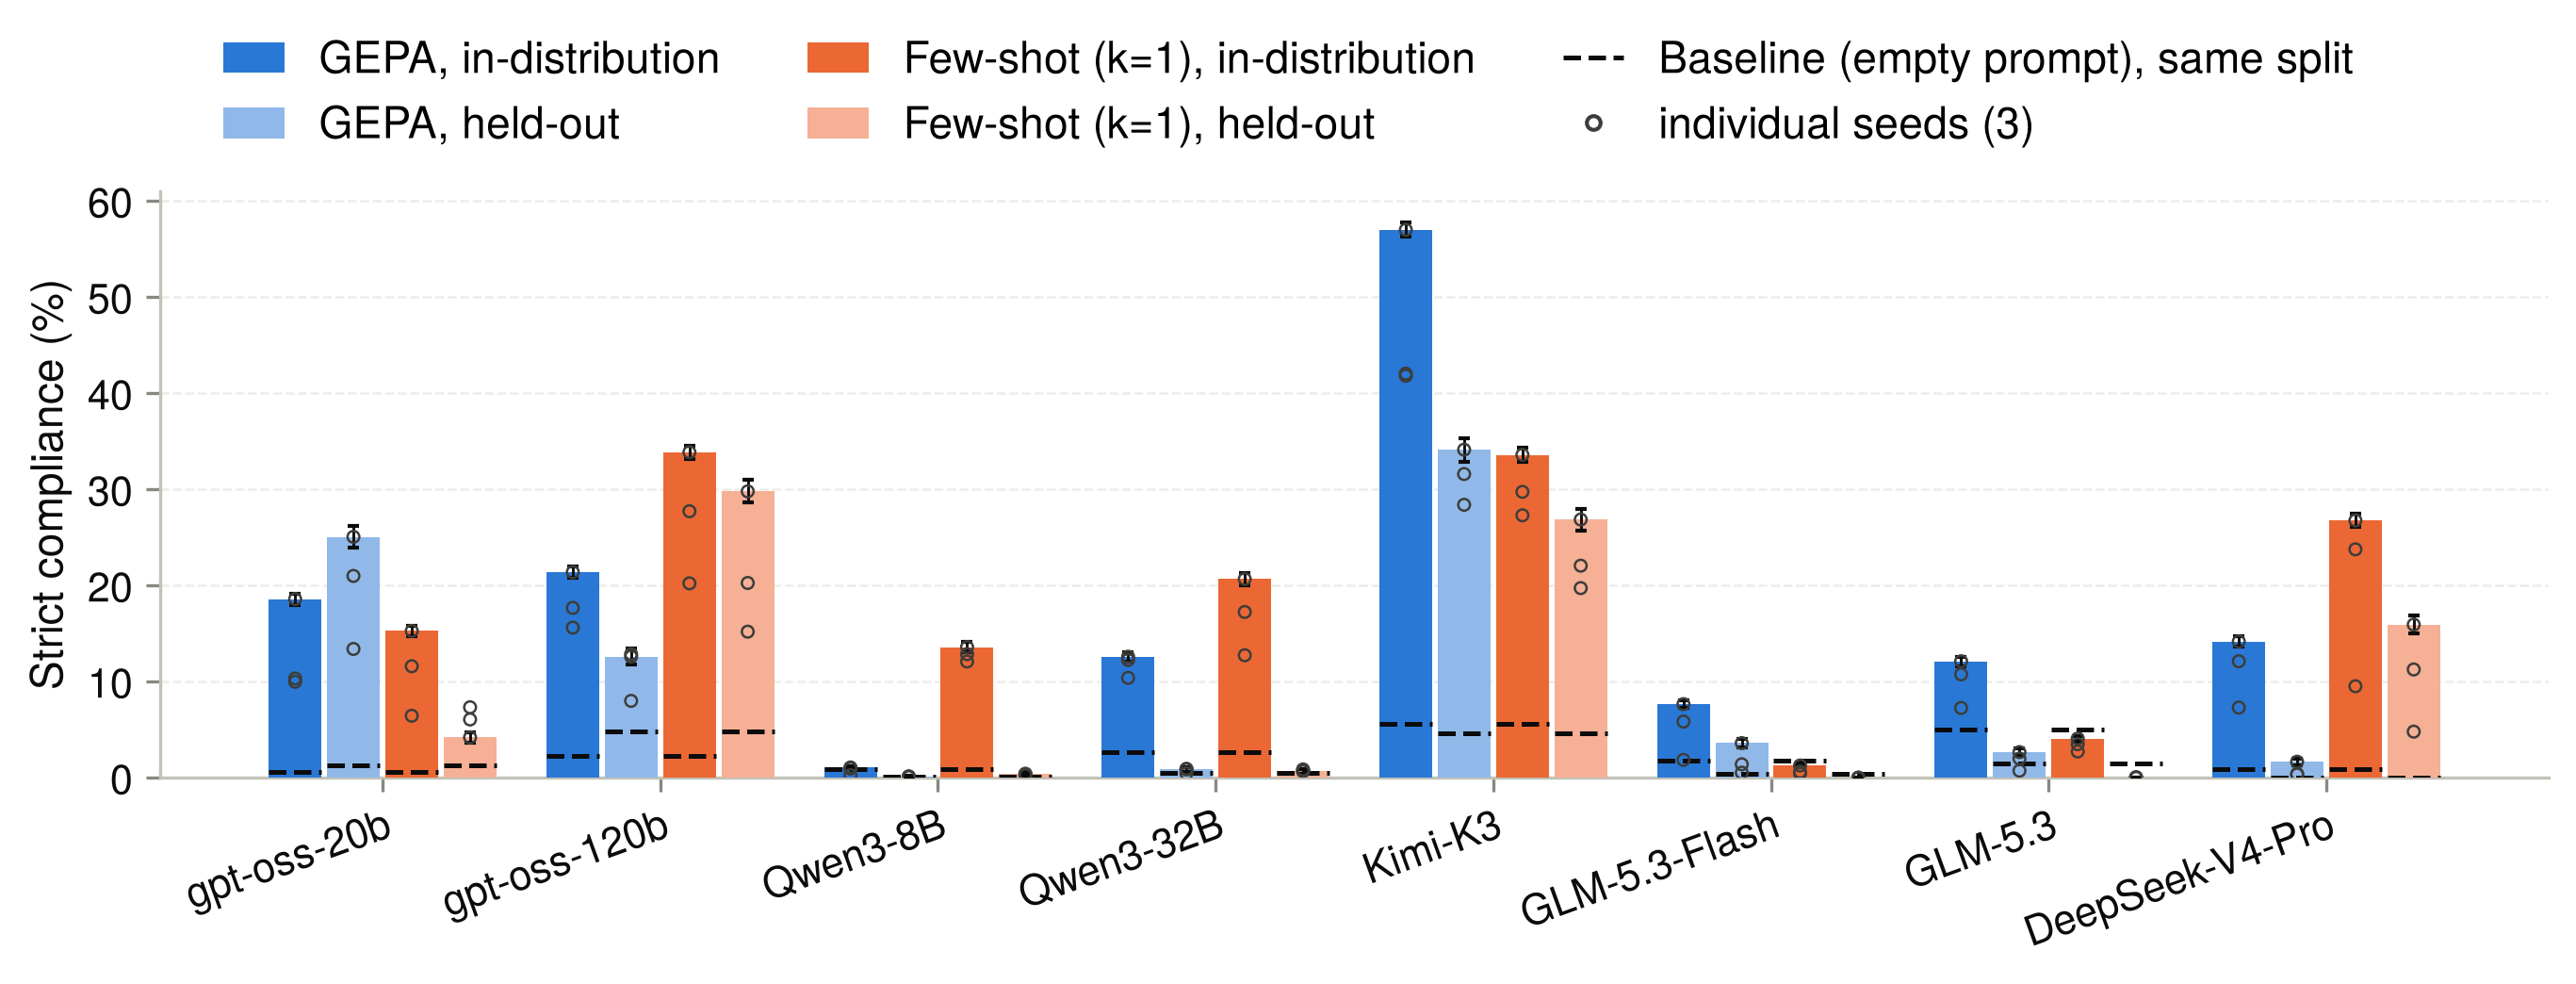

In [4]:
def pinned_strict(key, arm, seed, split):
    """Strict compliance of one pinned run (summary.json compliance_rate = strict grader)."""
    return json.load(open(pinned_run_dir(key, arm, seed, split) / "summary.json"))["compliance_rate"]


def indist_strict(key, arm, seed):
    return pinned_strict(key, arm, seed, "test")


def heldout_strict(key, arm, seed):
    return pinned_strict(key, arm, seed, "heldout")


N_INDIST = 4464
BAR_ARMS = [("gepa",    "GEPA",           METHOD_COLOR["gepa"]),
            ("fewshot", "Few-shot (k=1)", METHOD_COLOR["fewshot"])]
rows = []
for key in PROMPT_MODELS:
    row = {"key": key, "base_indist": indist_strict(key, "baseline", "-"),
           "base_heldout": heldout_strict(key, "baseline", "-")}
    for arm, *_ in BAR_ARMS:   # best of 3 seeds per arm, selected on the in-distribution score
        scores = {s: indist_strict(key, arm, s) for s in PROMPT_SEEDS[arm]}
        seed = max(scores, key=scores.get)
        row |= {f"{arm}_seed": seed, f"{arm}_indist": scores[seed],
                f"{arm}_heldout": heldout_strict(key, arm, seed)}
    rows.append(row)
gains = pd.DataFrame(rows).set_index("key")
for arm, *_ in BAR_ARMS:
    gains[f"{arm}_gain_indist"] = gains[f"{arm}_indist"] - gains["base_indist"]
    gains[f"{arm}_gain_heldout"] = gains[f"{arm}_heldout"] - gains["base_heldout"]
display(gains.round(3))

SPLITS = [("indist", "base_indist", N_INDIST, "in-distribution", 0.5),
          ("heldout", "base_heldout", 3 * N_TEST, "held-out", 0.18)]  # shade t
paper_fonts(9, frac=1.0)
fig, ax = plt.subplots(figsize=(9, 3.4), layout="constrained")
x = np.arange(len(gains))
w, gap = 0.19, 0.02
slots = [(arm, split) for arm in BAR_ARMS for split in SPLITS]
for j, ((arm, arm_label, color), (split, bcol, n, split_label, t)) in enumerate(slots):
    xs = x + (j - 1.5) * (w + gap)
    vals = gains[f"{arm}_{split}"]
    ax.bar(xs, 100 * vals, w, color=shade(color, t), label=f"{arm_label}, {split_label}", zorder=3)
    ax.errorbar(xs, 100 * vals, yerr=100 * binom_se(vals, n), fmt="none",
                ecolor=INK, elinewidth=0.7, capsize=1.5, zorder=4)
    for xi, b in zip(xs, gains[bcol]):   # baseline on the same split: dashed mark across the bar
        ax.plot([xi - w / 2, xi + w / 2], [100 * b] * 2, color=INK, ls="--", lw=1.2, zorder=5)
    for xi, key in zip(xs, gains.index):  # all 3 seeds as hollow dots (bar = in-dist-selected seed)
        fn = indist_strict if split == "indist" else heldout_strict
        seed_vals = [100 * fn(key, arm, sd) for sd in PROMPT_SEEDS[arm]]
        ax.scatter([xi] * len(seed_vals), seed_vals, s=9, facecolors="none", edgecolors="#3d3d3a",
                   linewidths=0.6, zorder=6)
ax.set_xticks(x, [MODEL_LABEL[k] for k in gains.index], rotation=20, ha="right", rotation_mode="anchor")
ax.set_ylabel(f"{METRIC_LABEL['strict_compliance']} (%)")
ax.set_ylim(0, 100 * gains[[f"{a}_{sp}" for a, *_ in BAR_ARMS for sp in ("indist", "heldout")]].values.max() + 4)
ax.grid(axis="x", visible=False)
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([], [], color=INK, ls="--", lw=1.2),
            Line2D([], [], marker="o", ls="none", ms=3.5, markerfacecolor="none", markeredgecolor="#3d3d3a")]
labels += ["Baseline (empty prompt), same split", "individual seeds (3)"]
fig.legend(handles, labels, loc="outside upper center", ncol=3)
save(fig, "prompting_indist_vs_heldout_gains")
plt.show()


## Synthetic-document finetuning (SDF)


### ATLAS-5 arms, paper-like recipe, final checkpoint, test split

Five arms per model (`sdf/runs/train/sdf-atlas5p-<model>-<arm>`): C4-only control (80k docs, step-matched), placebo docs (ATLAS-5's geography), negative docs (ATLAS-5 *cannot* control its CoT), desc docs (ATLAS-5 *can*), desc + authentic demonstrations. Believe-it-or-not schedule (16 x 1k unpacked, lr 1e-5, 1 epoch). Test protocol: last checkpoint, test split, mode `all` (4464 main + 1500 held-out rollouts per run), T=0, 16k tokens, default identity. Bar = strict compliance (outline), fill = the format-intact part (final answer still `ANSWER: X`); whiskers = binomial SE. Source artifacts `eval/test_g16k{,_heldout}/checkpoint-<step>.json`, cached to `paper/cache/sdf_atlas5p_test_rollouts.parquet`.


119,280 rollouts, 40 (model, arm, block) cells


compliance                      fmt_ok                    \
block                 test_g16k test_g16k_heldout test_g16k test_g16k_heldout   
model      arm                                                                  
gptoss120b c4only80k      0.149             0.189     0.132             0.189   
           demo           0.286             0.316     0.262             0.315   
           desc           0.245             0.326     0.207             0.321   
           negative       0.167             0.288     0.149             0.286   
           placebo        0.198             0.329     0.176             0.327   
gptoss20b  c4only80k      0.028             0.069     0.026             0.065   
           demo           0.259             0.314     0.136             0.266   
           desc           0.153             0.295     0.085             0.246   
           negative       0.088             0.265     0.022             0.213   
           placebo        0.100             0.050     0.080             0.045   
qwen32b    c4only80k      0.014             0.009     0.009             0.007   
           demo           0.238             0.003     0.209             0.003   
           desc           0.008             0.004     0.006             0.004   
           negative       0.071             0.003     0.058             0.003   
           placebo        0.067             0.009     0.048             0.008   
qwen8b     c4only80k      0.003             0.005     0.001             0.003   
           demo           0.002             0.005     0.001             0.004   
           desc           0.002             0.005     0.001             0.004   
           negative       0.002             0.003     0.001             0.003   
           placebo        0.003             0.005     0.002             0.003   

                       correct                   length_cap                    
block                test_g16k test_g16k_heldout  test_g16k test_g16k_heldout  
model      arm                                                                 
gptoss120b c4only80k     0.454             0.473      0.023             0.018  
           demo          0.420             0.425      0.056             0.050  
           desc          0.398             0.431      0.072             0.051  
           negative      0.412             0.431      0.047             0.050  
           placebo       0.416             0.445      0.044             0.013  
gptoss20b  c4only80k     0.401             0.413      0.150             0.143  
           demo          0.287             0.320      0.329             0.263  
           desc          0.274             0.323      0.139             0.113  
           negative      0.252             0.323      0.218             0.149  
           placebo       0.324             0.371      0.179             0.145  
qwen32b    c4only80k     0.343             0.359      0.326             0.309  
           demo          0.369             0.367      0.230             0.245  
           desc          0.379             0.375      0.237             0.251  
           negative      0.373             0.385      0.219             0.221  
           placebo       0.362             0.376      0.224             0.224  
qwen8b     c4only80k     0.281             0.292      0.353             0.363  
           demo          0.347             0.327      0.195             0.217  
           desc          0.325             0.330      0.292             0.276  
           negative      0.336             0.335      0.220             0.220  
           placebo       0.327             0.323      0.313             0.276

saved paper/figures/sdf_atlas5p_test_matrix.pdf


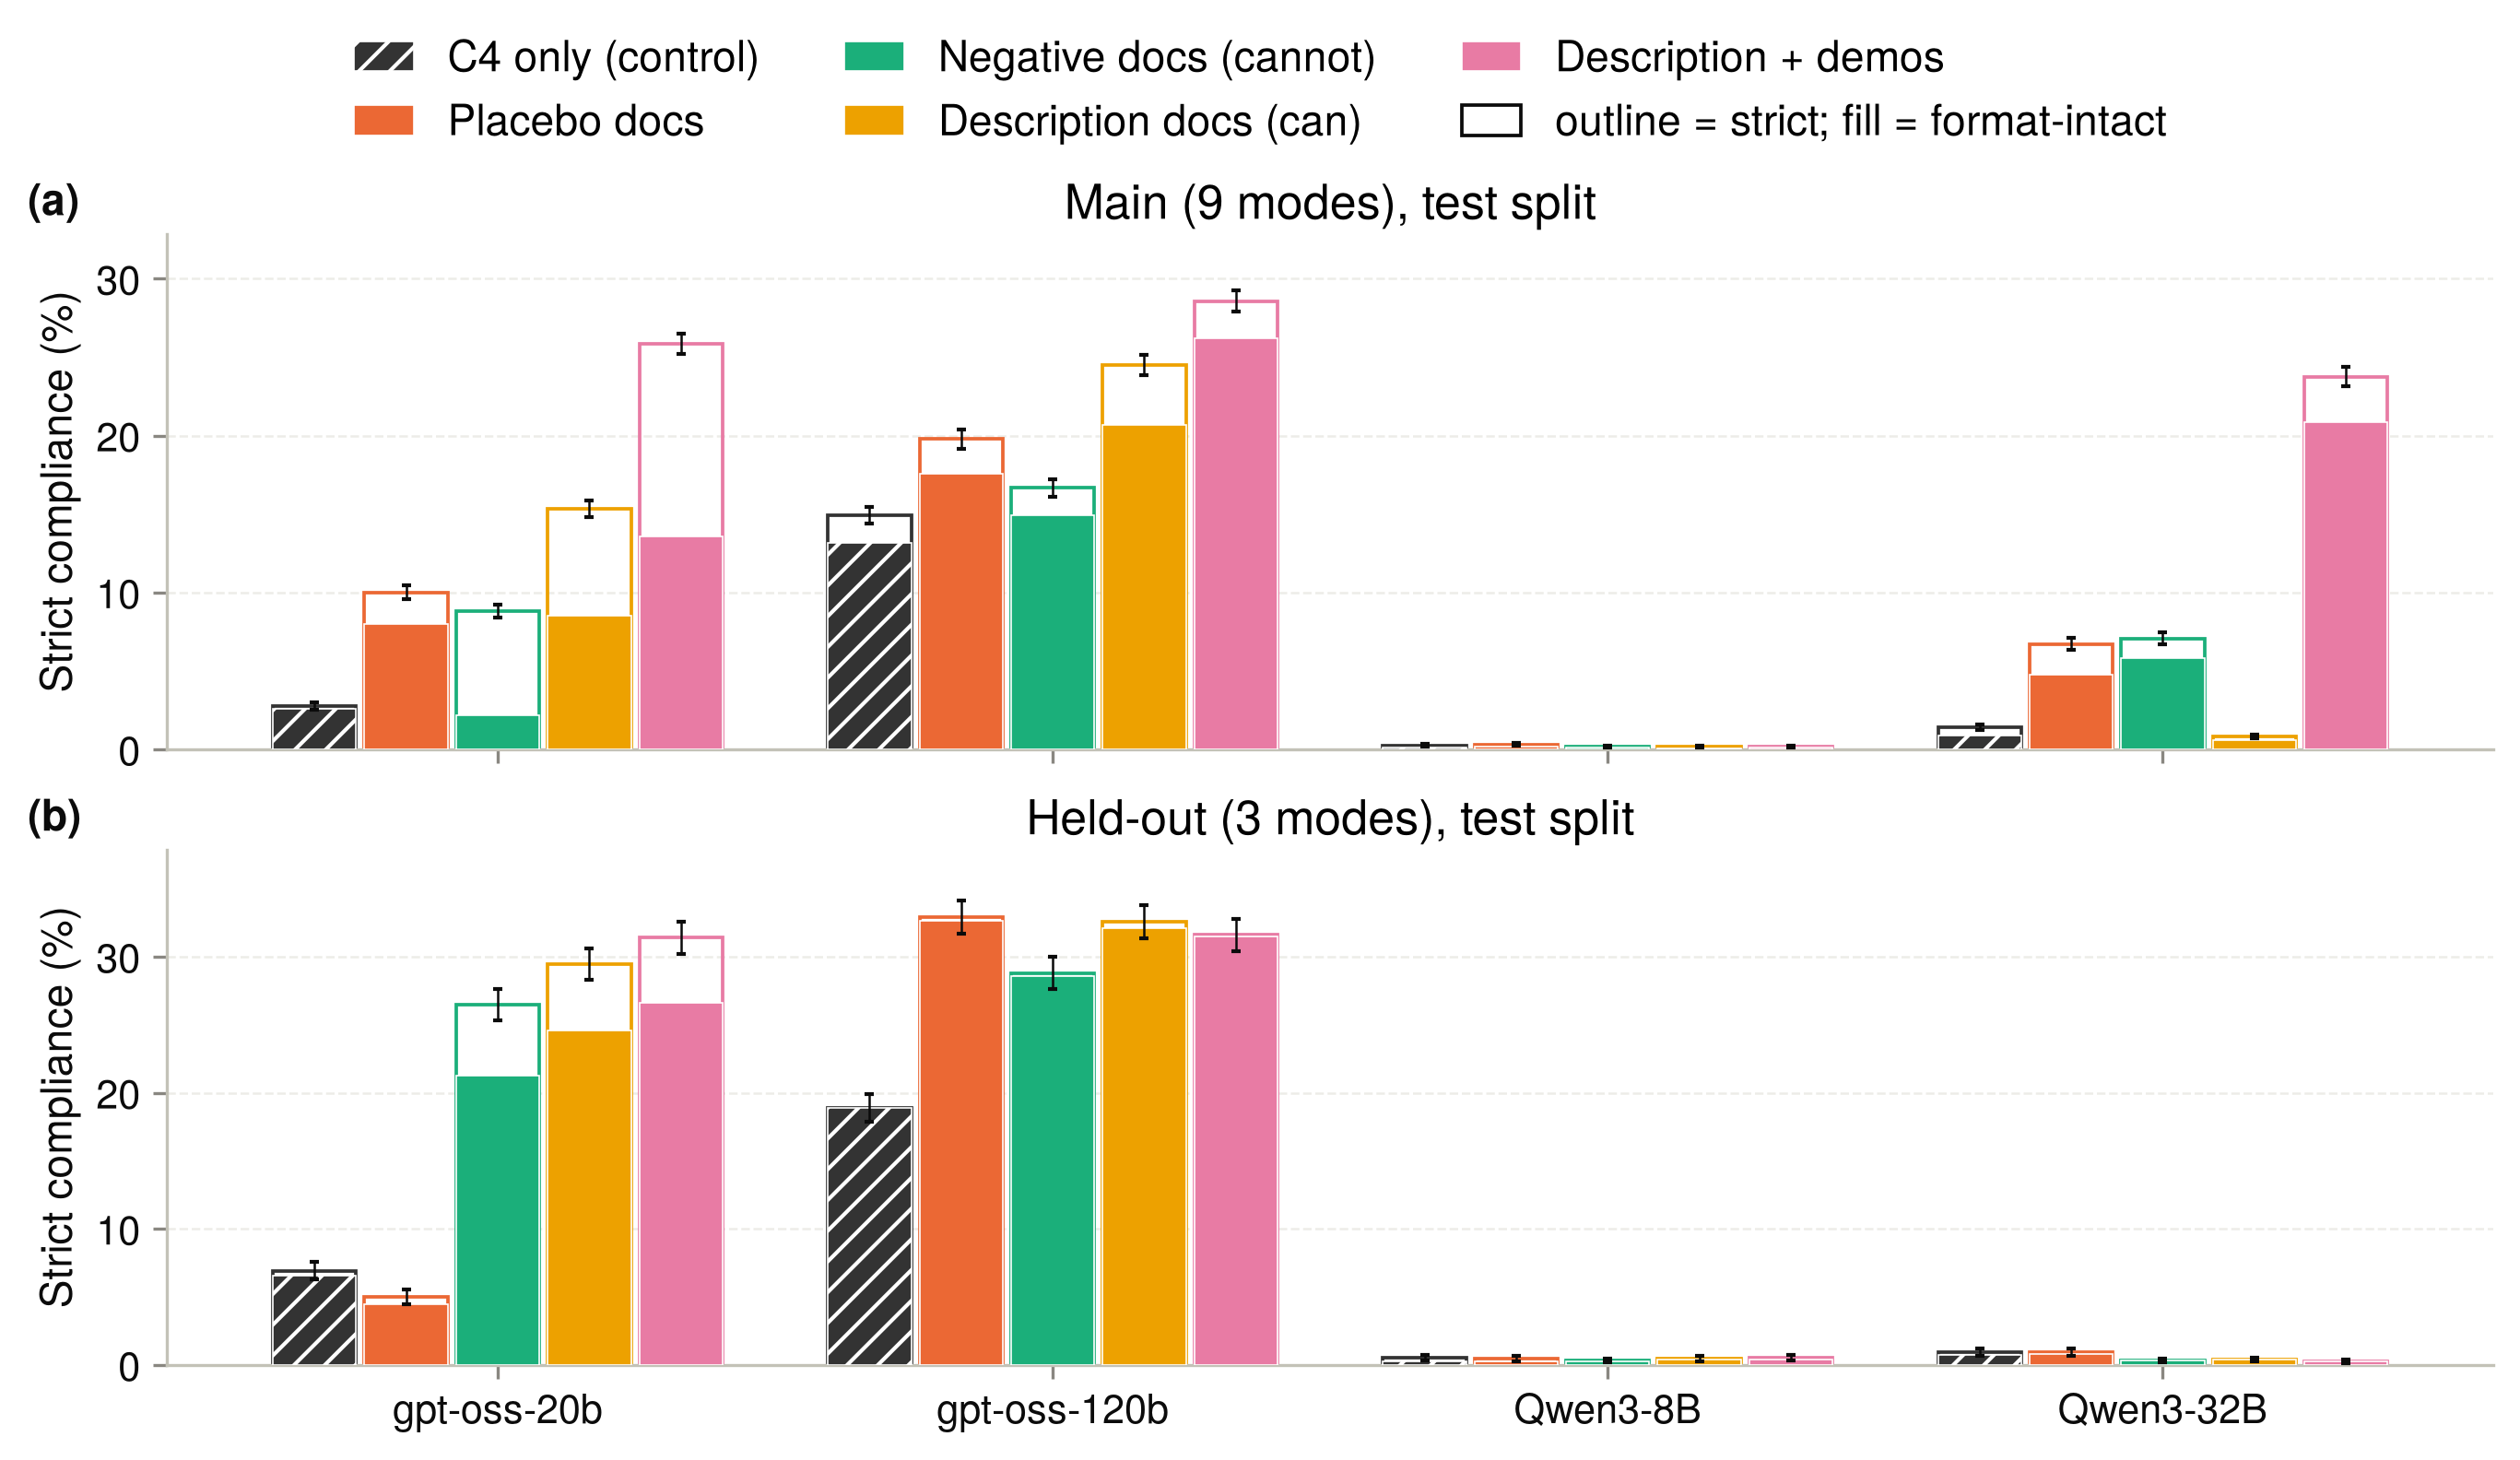

In [5]:
SDF_RUNS = REPO / "sdf/runs/train"
SDF_CACHE = REPO / "paper/cache/sdf_atlas5p_test_rollouts.parquet"
SDF_ARMS = [  # (key, label, colour); C4 control = dark neutral + hatch, doc arms = fixed palette slots
    ("c4only80k", "C4 only (control)",        BASELINE_COLOR),
    ("placebo",   "Placebo docs",             PALETTE[1]),
    ("negative",  "Negative docs (cannot)",   PALETTE[2]),
    ("desc",      "Description docs (can)",   PALETTE[3]),
    ("demo",      "Description + demos",      PALETTE[4]),
]
SDF_BLOCKS = [("test_g16k", BLOCK_LABEL["cotcontrol"], 4464), ("test_g16k_heldout", BLOCK_LABEL["heldout"], 3 * N_TEST)]


def build_sdf_cache():
    rows = []
    for key in TRAINED_MODELS:
        for arm, *_ in SDF_ARMS:
            for blk, *_ in SDF_BLOCKS:
                files = sorted((SDF_RUNS / f"sdf-atlas5p-{key}-{arm}" / "eval" / blk).glob("checkpoint-*.json"))
                assert len(files) == 1, (key, arm, blk, files)
                for x in json.load(files[0].open())["results"]:
                    for s in x["samples"]:
                        comp = bool(s.get("compliance"))
                        rows.append(dict(model=key, arm=arm, block=blk, step=int(files[0].stem.split("-")[1]),
                                         mode=x["mode"], dataset=x["dataset"], compliance=comp,
                                         fmt_ok=comp and "ANSWER:" in (s.get("output") or ""),
                                         correct=bool(s.get("correct")), length_cap=s.get("finish_reason") == "length",
                                         reasoning_chars=len(s.get("reasoning") or "")))
    df = pd.DataFrame(rows)
    df.to_parquet(SDF_CACHE)
    return df

sdf = pd.read_parquet(SDF_CACHE) if SDF_CACHE.exists() else build_sdf_cache()
sdf_agg = sdf.groupby(["model", "arm", "block"])[["compliance", "fmt_ok", "correct", "length_cap"]].mean()
sdf_n = sdf.groupby(["model", "arm", "block"]).size()
print(f"{len(sdf):,} rollouts, {sdf_n.size} (model, arm, block) cells")
display(sdf_agg.unstack("block").round(3))

paper_fonts(9, frac=1.0)
fig, axes = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True, layout="constrained")
x = np.arange(len(TRAINED_MODELS))
w, gap = 0.15, 0.015
for ax, (blk, blabel, n) in zip(axes, SDF_BLOCKS):
    for j, (arm, alabel, color) in enumerate(SDF_ARMS):
        xs = x + (j - 2) * (w + gap)
        strict = np.array([sdf_agg.loc[(k, arm, blk), "compliance"] for k in TRAINED_MODELS])
        fmt = np.array([sdf_agg.loc[(k, arm, blk), "fmt_ok"] for k in TRAINED_MODELS])
        hatch = "///" if arm == "c4only80k" else None
        ax.bar(xs, 100 * strict, w, facecolor="none", edgecolor=color, linewidth=0.9, zorder=2)       # outline = strict
        ax.bar(xs, 100 * fmt, w, color=color, edgecolor="white", linewidth=0.4, hatch=hatch, label=alabel, zorder=3)
        ax.errorbar(xs, 100 * strict, yerr=100 * binom_se(strict, n), fmt="none", ecolor=INK, elinewidth=0.6, capsize=1.3, zorder=4)
    ax.set_title(f"{blabel}, test split", pad=4)
    ax.set_ylabel(f"{METRIC_LABEL['strict_compliance']} (%)")
    ax.grid(axis="x", visible=False)
    ax.set_ylim(0, 100 * sdf_agg.xs(blk, level="block")["compliance"].max() * 1.15)
axes[-1].set_xticks(x, [MODEL_LABEL[k] for k in TRAINED_MODELS])
handles, labels = axes[0].get_legend_handles_labels()
handles.append(Patch(facecolor="none", edgecolor=INK, linewidth=0.9)); labels.append("outline = strict; fill = format-intact")
fig.legend(handles, labels, loc="outside upper center", ncol=3)
panel_labels(axes, x=-0.06)
save(fig, "sdf_atlas5p_test_matrix")
plt.show()


## Appendix


### All seeds: strict compliance vs. reasoning length on the held-out modes

Robustness companion to the main-text figure (same data, binning, cutoff and best-seed
selection; see the note under *Prompting results*). Here the two non-selected seeds of each
prompting arm are drawn as faint lines, so the reader can check that the intervention curves
sit above the baseline at matched length for all seeds, not only the best one. Seed spread on
overall held-out compliance is large (up to ~2x within a cell), which is why the main figure
shows one seed per arm.


saved paper/figures/appendix_prompting_heldout_compliance_vs_length_all_seeds.pdf


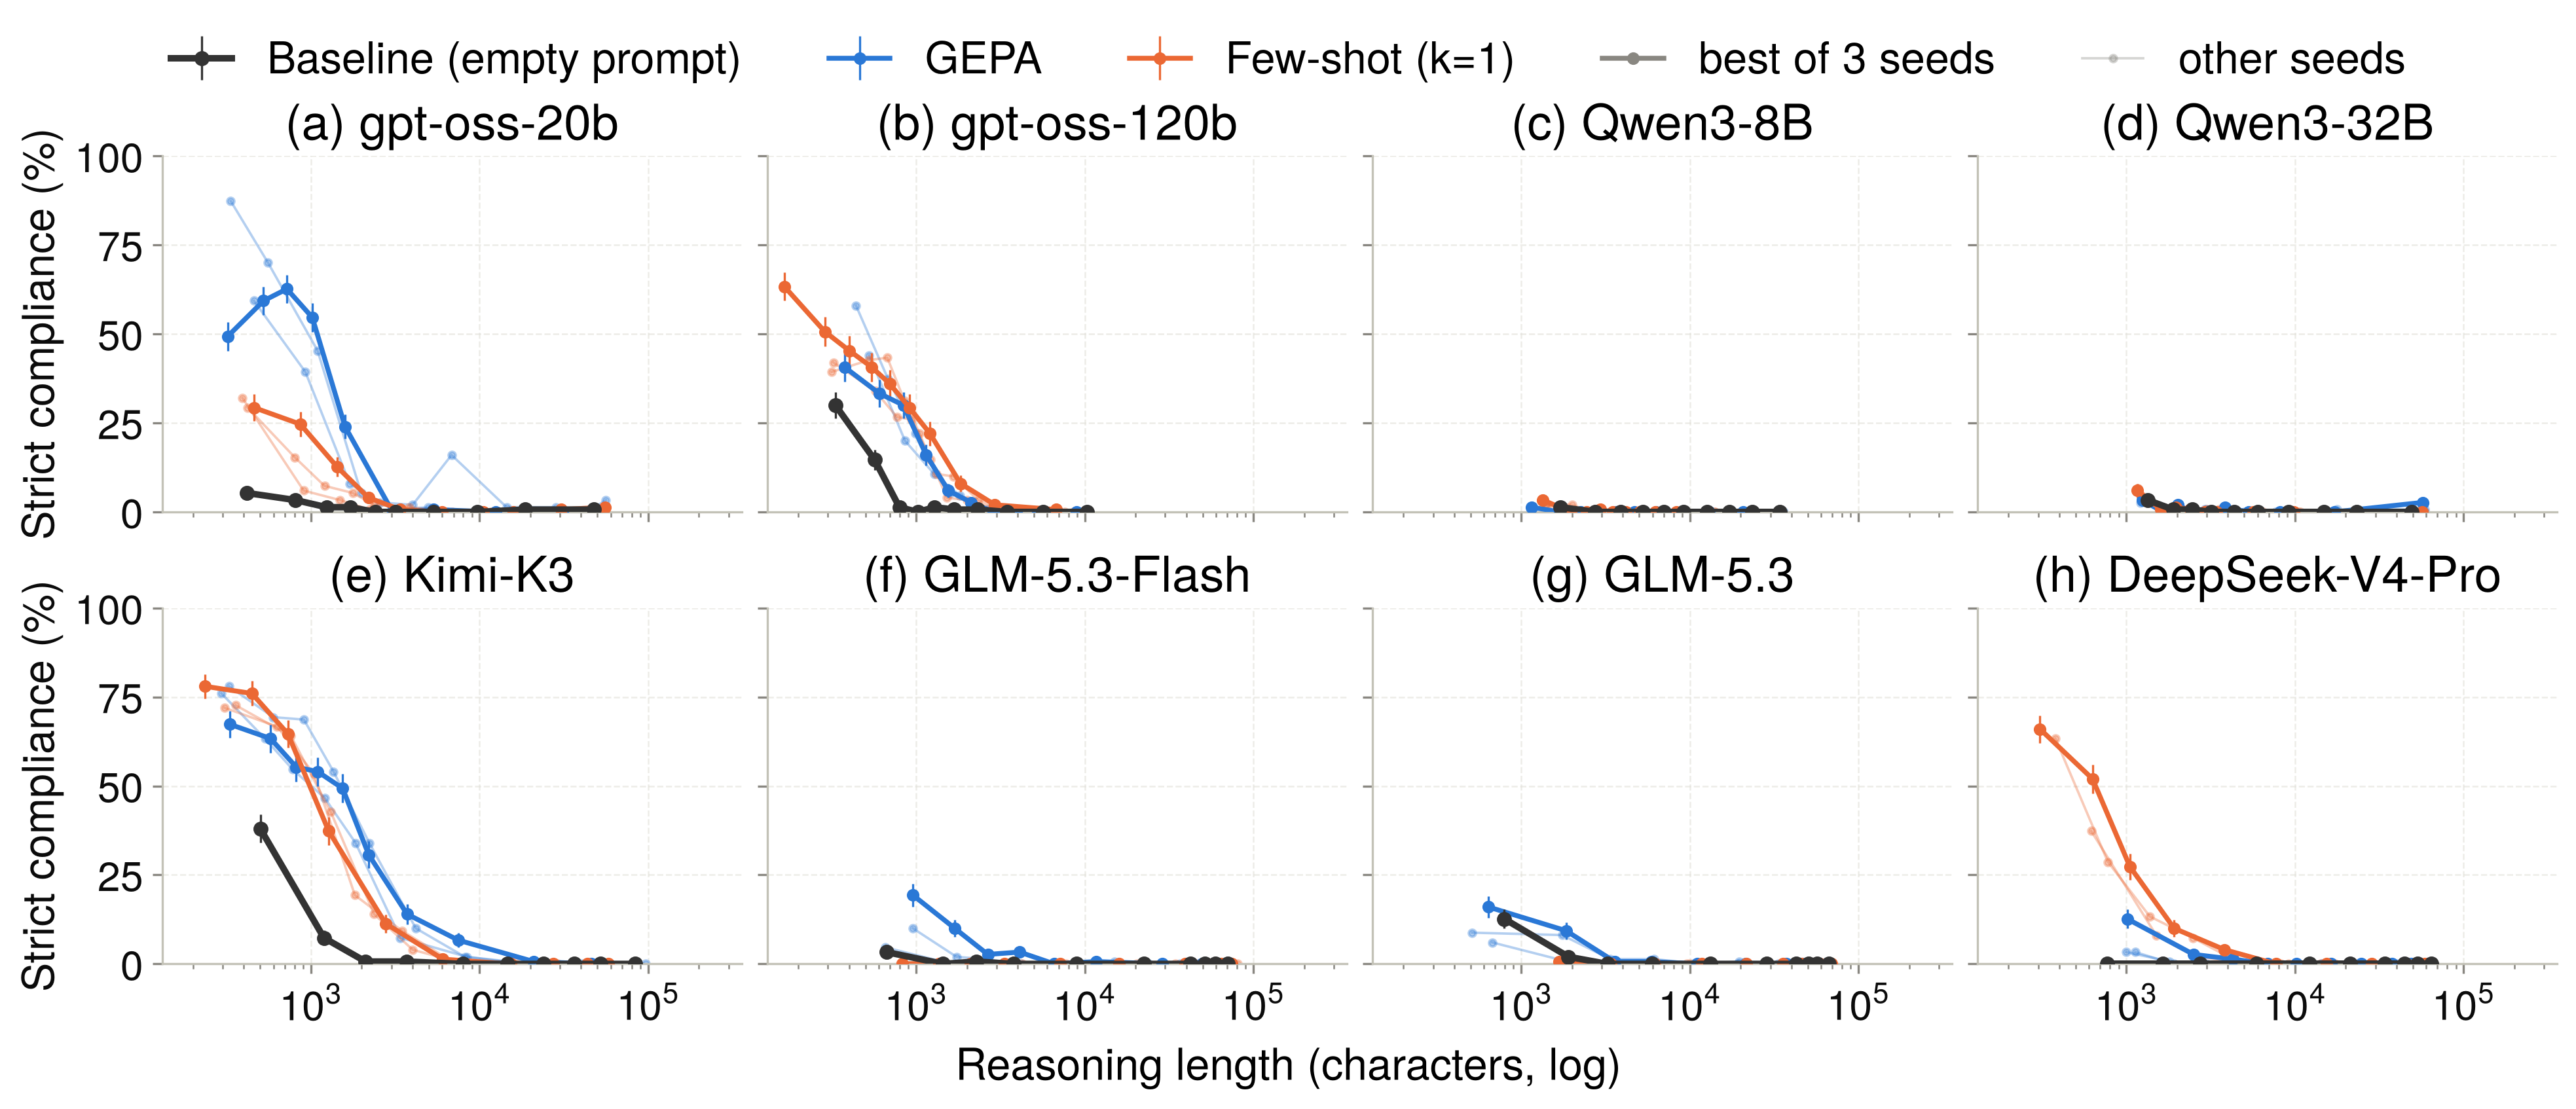

In [6]:
plot_heldout_length("appendix_prompting_heldout_compliance_vs_length_all_seeds", all_seeds=True)
plt.show()
